In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parents[0]  # adjust if running in notebook
sys.path.append(str(repo_root / "vis" / "python"))

import bin_convert_new as bc

In [224]:
N = 50
out_dict = bc.read_binary_as_athdf(f"bin/Conv.hydro_w.{N:05d}.bin")
print(out_dict.keys())

dict_keys(['x1f', 'x1v', 'x2f', 'x2v', 'x3f', 'x3v', 'dens', 'velx', 'vely', 'velz', 'eint', 's_00', 's_01', 's_02', 's_03', 's_04', 'Time', 'NumCycles', 'MaxLevel'])


(array([ 100.,  180.,  480.,  443.,  837.,  800.,  969., 1151., 1204.,
        1576., 1260., 1260., 1344., 1278., 1378., 1381., 1302., 1337.,
        1420., 1482., 1499., 1539., 1501., 1660., 1539., 1700., 1620.,
        2018., 2265., 2237., 2381., 2496., 2523., 2777., 3117., 2704.,
        2741., 2315., 2541., 2843., 2444., 2834., 2666., 2541., 2858.,
        1641.,  819.,  418.,  301.,  200.]),
 array([-1.2728852 , -1.25459087, -1.23629653, -1.2180022 , -1.19970798,
        -1.18141365, -1.16311932, -1.14482498, -1.12653065, -1.10823631,
        -1.08994198, -1.07164764, -1.05335331, -1.03505909, -1.01676476,
        -0.99847043, -0.98017609, -0.96188176, -0.94358742, -0.92529315,
        -0.90699881, -0.88870448, -0.8704102 , -0.85211587, -0.83382154,
        -0.8155272 , -0.79723287, -0.77893859, -0.76064426, -0.74234992,
        -0.72405565, -0.70576131, -0.68746698, -0.66917264, -0.65087831,
        -0.63258404, -0.6142897 , -0.59599537, -0.57770109, -0.55940676,
        -0.54111

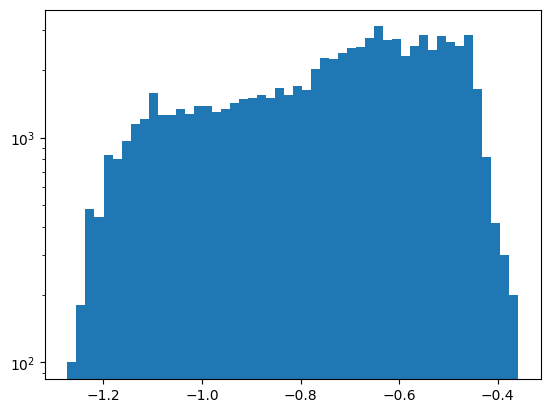

In [225]:
# plt.hist(out_dict["dens"].flatten(), bins=50, log=True)
plt.hist(np.log10(out_dict["dens"]).flatten(), bins=50, log=True)

In [4]:
gamma_minus_1 = 5.0 / 3.0 - 1.0


def compute_temperature(out_dict):
    KE = (
        0.5
        * out_dict["dens"]
        * (out_dict["velx"] ** 2 + out_dict["vely"] ** 2 + out_dict["velz"] ** 2)
    )
    TE = out_dict["eint"] - KE

    T = (TE * gamma_minus_1) / out_dict["dens"]

    return T

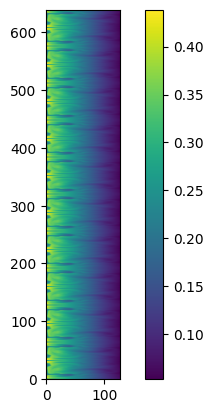

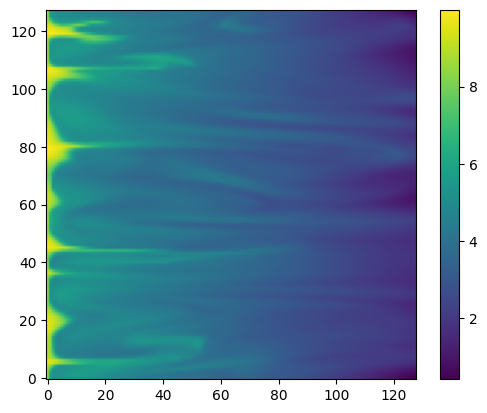

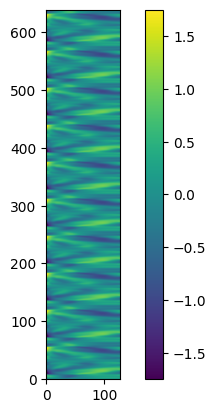

In [ ]:
plt.figure()
plt.imshow(out_dict["dens"][0, :, :], origin="lower")
aspect = "equal"
plt.colorbar()

plt.figure()
plt.imshow(T[0, :, :], origin="lower")
aspect = "equal"
plt.colorbar()

plt.figure()
plt.imshow(out_dict["vely"][0, :, :], origin="lower")
aspect = "equal"
plt.colorbar()

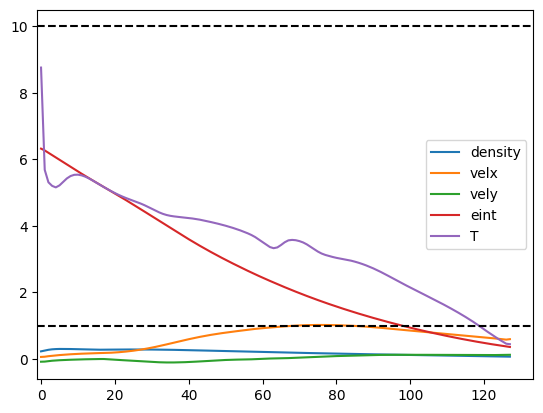

In [ ]:
plt.plot(out_dict["dens"][0, 0, :], label="density")
plt.plot(out_dict["velx"][0, 0, :], label="velx")
plt.plot(out_dict["vely"][0, 0, :], label="vely")
plt.plot(out_dict["eint"][0, 0, :], label="eint")
plt.plot(T[0, 0, :], label="T")

plt.axhline(1.0, color="k", ls="--")
plt.axhline(10.0, color="k", ls="--")

plt.xlim(-1, None)
plt.legend()

In [ ]:
import cmasher as cm

for i in range(501):
    fig = plt.figure(figsize=(16, 3))
    out_dict = bc.read_binary_as_athdf(f"bin/Conv.hydro_w.{i:05d}.bin")
    plt.imshow(
        compute_temperature(out_dict)[0, :, :].T,
        # (out_dict["s_00"] / out_dict["dens"])[0, :, :].T,
        origin="lower",
        aspect="equal",
        vmin=9.5,
        vmax=10.5,
        cmap=cm.bubblegum,
        # cmap=cm.redshift,
    )
    plt.colorbar()
    fig.savefig(f"save/temp/temp_{i:05d}.png")
    plt.close(fig)

FileNotFoundError: [Errno 2] No such file or directory: 'bin/Conv.hydro_w.00446.bin'

<Figure size 1600x300 with 0 Axes>